# Stage 3: Data Preprocessing & Cleaning
## Heart Disease Prediction Using Patient Health Data

This stage prepares the raw Cleveland dataset for modelling by handling outliers, encoding features, scaling numerical values, and producing a clean train/test split.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import os
import warnings

warnings.filterwarnings('ignore')
os.makedirs('plots', exist_ok=True)
os.makedirs('data', exist_ok=True)

plt.rcParams['figure.dpi'] = 130
PALETTE = ['#e74c3c', '#2ecc71']

print("Libraries loaded. Starting Stage 3: Preprocessing & Cleaning.")

Libraries loaded. Starting Stage 3: Preprocessing & Cleaning.


## 3.1 Load Raw Data

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Anagha\Downloads\Heart-disease-prediction\Heart-disease-prediction\heart-disease.csv")

print(df.head())

print(f"Raw dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Anagha\\Downloads\\Heart-disease-prediction\\Heart-disease-prediction\\heart-disease.csv'

## 3.2 Step 1 — Verify No Missing Values

In [ ]:
missing_count = df.isnull().sum()
print("Missing values per column:")
print(missing_count)
print(f"\nTotal missing: {missing_count.sum()}")

# Confirm
assert missing_count.sum() == 0, "Unexpected missing values found!"
print("\n✅ Confirmed: No missing values. No imputation required.")

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing: 0

✅ Confirmed: No missing values. No imputation required.


## 3.3 Step 2 — Check for Duplicate Rows

In [ ]:
dups = df.duplicated().sum()
print(f"Duplicate rows: {dups}")

if dups > 0:
    df = df.drop_duplicates()
    print(f"Dropped {dups} duplicate rows. New shape: {df.shape}")
else:
    print("✅ No duplicates found. Shape unchanged:", df.shape)

Duplicate rows: 1
Dropped 1 duplicate rows. New shape: (302, 14)


## 3.4 Step 3 — Validate Feature Ranges (Domain Constraints)

In [ ]:
# Define clinically plausible ranges for each feature
constraints = {
    'age':      (20, 90,   'years'),
    'sex':      (0,  1,    'binary 0/1'),
    'cp':       (0,  3,    'ordinal 0–3'),
    'trestbps': (80, 250,  'mm Hg'),
    'chol':     (100, 600, 'mg/dl'),
    'fbs':      (0,  1,    'binary 0/1'),
    'restecg':  (0,  2,    'ordinal 0–2'),
    'thalach':  (60, 220,  'bpm'),
    'exang':    (0,  1,    'binary 0/1'),
    'oldpeak':  (0,  8,    'depression unit'),
    'slope':    (0,  2,    'ordinal 0–2'),
    'ca':       (0,  4,    'vessels 0–4'),
    'thal':     (0,  3,    'ordinal 0–3'),
}

print("DOMAIN CONSTRAINT VALIDATION")
print("=" * 65)
all_ok = True
for col, (low, high, unit) in constraints.items():
    violations = df[(df[col] < low) | (df[col] > high)].shape[0]
    status = "✅ OK" if violations == 0 else f"⚠️  {violations} violations"
    print(f"  {col:<12} range [{low} – {high}] {unit:<22}  {status}")
    if violations > 0:
        all_ok = False

print()
if all_ok:
    print("All features are within clinically plausible ranges.")
else:
    print("Some violations found — investigate further.")

DOMAIN CONSTRAINT VALIDATION
  age          range [20 – 90] years                   ✅ OK
  sex          range [0 – 1] binary 0/1              ✅ OK
  cp           range [0 – 3] ordinal 0–3             ✅ OK
  trestbps     range [80 – 250] mm Hg                   ✅ OK
  chol         range [100 – 600] mg/dl                   ✅ OK
  fbs          range [0 – 1] binary 0/1              ✅ OK
  restecg      range [0 – 2] ordinal 0–2             ✅ OK
  thalach      range [60 – 220] bpm                     ✅ OK
  exang        range [0 – 1] binary 0/1              ✅ OK
  oldpeak      range [0 – 8] depression unit         ✅ OK
  slope        range [0 – 2] ordinal 0–2             ✅ OK
  ca           range [0 – 4] vessels 0–4             ✅ OK
  thal         range [0 – 3] ordinal 0–3             ✅ OK

All features are within clinically plausible ranges.


## 3.5 Step 4 — Outlier Detection (IQR Method)

In [ ]:
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

print("OUTLIER DETECTION — IQR METHOD")
print("=" * 55)

outlier_summary = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_summary[col] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Fence': lower, 'Upper Fence': upper,
        'Outlier Count': n_outliers
    }
    print(f"  {col:<12}  Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}  "
          f"Fences=[{lower:.1f}, {upper:.1f}]  Outliers={n_outliers}")

print("\nDecision: We retain all outliers because:")
print("  (a) They are clinically plausible (no measurement errors).")
print("  (b) Extreme cholesterol or BP values are real risk indicators.")
print("  (c) Removing them would bias the model and reduce generalisability.")

OUTLIER DETECTION — IQR METHOD
  age           Q1=48.0  Q3=61.0  IQR=13.0  Fences=[28.5, 80.5]  Outliers=0
  trestbps      Q1=120.0  Q3=140.0  IQR=20.0  Fences=[90.0, 170.0]  Outliers=9
  chol          Q1=211.0  Q3=274.8  IQR=63.8  Fences=[115.4, 370.4]  Outliers=5
  thalach       Q1=133.2  Q3=166.0  IQR=32.8  Fences=[84.1, 215.1]  Outliers=1
  oldpeak       Q1=0.0  Q3=1.6  IQR=1.6  Fences=[-2.4, 4.0]  Outliers=5

Decision: We retain all outliers because:
  (a) They are clinically plausible (no measurement errors).
  (b) Extreme cholesterol or BP values are real risk indicators.
  (c) Removing them would bias the model and reduce generalisability.


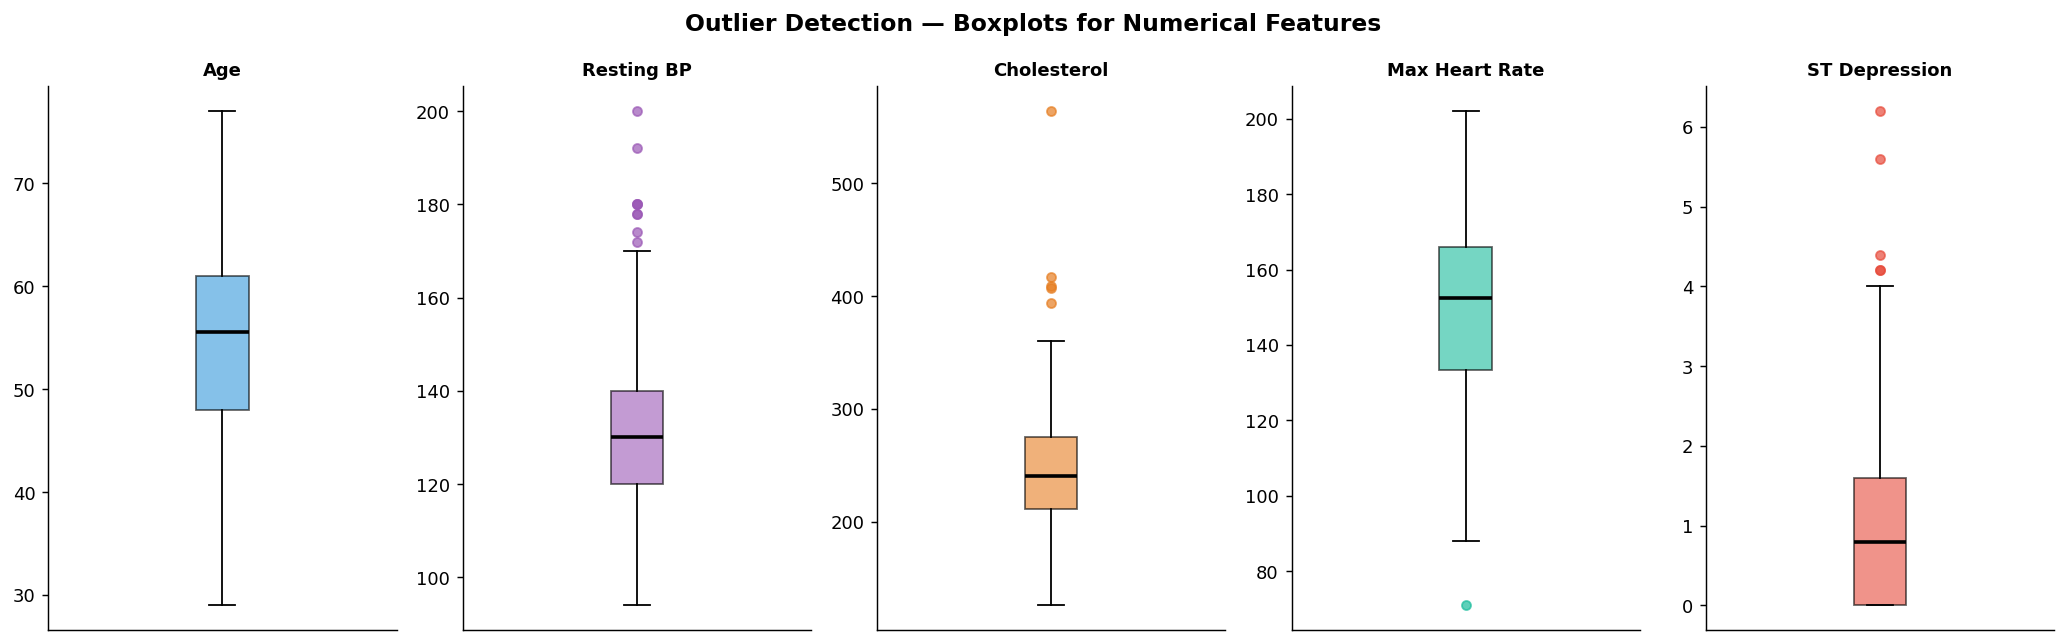

Saved successfully to: plots/outlier_boxplots.png


In [ ]:
import os
import matplotlib.pyplot as plt

# Create plots folder if it doesn't exist
os.makedirs("plots", exist_ok=True)

# Numerical columns
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Create subplots
fig, axes = plt.subplots(1, 5, figsize=(16, 5))

# Titles and colors
titles = ['Age', 'Resting BP', 'Cholesterol', 'Max Heart Rate', 'ST Depression']
colors = ['#3498db', '#9b59b6', '#e67e22', '#1abc9c', '#e74c3c']

# Draw boxplots
for ax, col, title, color in zip(axes, numerical_cols, titles, colors):

    ax.boxplot(
        df[col],
        patch_artist=True,
        notch=False,
        boxprops=dict(facecolor=color, alpha=0.6),
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(
            marker='o',
            markerfacecolor=color,
            markeredgecolor=color,
            alpha=0.7,
            markersize=5
        )
    )

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xticks([])

    # Remove extra borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Main title
plt.suptitle(
    'Outlier Detection — Boxplots for Numerical Features',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

# Save figure
plt.savefig(
    "plots/outlier_boxplots.png",
    dpi=150,
    bbox_inches='tight'
)

# Show plot
plt.show()

print("Saved successfully to: plots/outlier_boxplots.png")

## 3.6 Step 5 — Feature Type Classification

Before scaling, we identify which features are truly numerical (continuous) and which are categorical (even if encoded as integers).

In [ ]:
# Separate features by type
continuous_features  = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

print("FEATURE TYPE CLASSIFICATION")
print("=" * 50)
print(f"Continuous (to be scaled):   {continuous_features}")
print(f"Categorical (ordinal/binary): {categorical_features}")
print(f"Target variable:              ['target']")
print()
print("Note: Categorical features with integer encoding are kept as-is.")
print("      They represent ordinal or nominal categories, not magnitudes.")

FEATURE TYPE CLASSIFICATION
Continuous (to be scaled):   ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical (ordinal/binary): ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Target variable:              ['target']

Note: Categorical features with integer encoding are kept as-is.
      They represent ordinal or nominal categories, not magnitudes.


## 3.7 Step 6 — Train/Test Split (Stratified)

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

# Stratified split: maintains class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y      # ← ensures both splits have ~54.5% disease
)

print("TRAIN/TEST SPLIT SUMMARY (80/20, Stratified)")
print("=" * 50)
print(f"Total samples   : {len(df)}")
print(f"Training set    : {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Test set        : {X_test.shape[0]}  samples ({X_test.shape[0]/len(df)*100:.1f}%)")
print()
print("Class distribution in training set:")
train_dist = y_train.value_counts(normalize=True) * 100
print(f"  No Disease : {train_dist[0]:.1f}%")
print(f"  Disease    : {train_dist[1]:.1f}%")
print()
print("Class distribution in test set:")
test_dist = y_test.value_counts(normalize=True) * 100
print(f"  No Disease : {test_dist[0]:.1f}%")
print(f"  Disease    : {test_dist[1]:.1f}%")
print()
print("✅ Stratification confirmed: class ratios are preserved in both splits.")

TRAIN/TEST SPLIT SUMMARY (80/20, Stratified)
Total samples   : 302
Training set    : 241 samples (79.8%)
Test set        : 61  samples (20.2%)

Class distribution in training set:
  No Disease : 45.6%
  Disease    : 54.4%

Class distribution in test set:
  No Disease : 45.9%
  Disease    : 54.1%

✅ Stratification confirmed: class ratios are preserved in both splits.


## 3.8 Step 7 — Feature Scaling (StandardScaler)

In [ ]:
# StandardScaler: zero mean, unit variance
# Important: fit ONLY on training data to avoid data leakage
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled  = scaler.transform(X_test)         # transform only (no re-fit)

# Wrap back in DataFrames for readability
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("SCALING SUMMARY — StandardScaler")
print("=" * 55)
print("Formula: z = (x - mean) / std_dev")
print()
print("Scaler parameters (fitted on training set):")
scale_info = pd.DataFrame({
    'Feature': X.columns,
    'Training Mean': scaler.mean_.round(3),
    'Training Std':  scaler.scale_.round(3)
})
print(scale_info.to_string(index=False))
print()
print("After scaling — Training set stats (should be ~0 mean, ~1 std):")
print(pd.DataFrame(X_train_scaled_df[continuous_features].agg(['mean', 'std']).round(3)))
print()
print("Note: Categorical features are also scaled here for model compatibility.")
print("      Tree-based models (Gradient Boosting) are scale-invariant but we")
print("      scale uniformly so all models use the same preprocessed data.")

SCALING SUMMARY — StandardScaler
Formula: z = (x - mean) / std_dev

Scaler parameters (fitted on training set):
 Feature  Training Mean  Training Std
     age         54.340         9.201
     sex          0.685         0.465
      cp          0.938         1.002
trestbps        131.448        17.951
    chol        244.299        48.006
     fbs          0.141         0.348
 restecg          0.552         0.530
 thalach        150.071        22.041
   exang          0.340         0.474
 oldpeak          1.071         1.204
   slope          1.398         0.624
      ca          0.730         1.021
    thal          2.344         0.599

After scaling — Training set stats (should be ~0 mean, ~1 std):
        age  trestbps   chol  thalach  oldpeak
mean  0.000    -0.000  0.000   -0.000   -0.000
std   1.002     1.002  1.002    1.002    1.002

Note: Categorical features are also scaled here for model compatibility.
      Tree-based models (Gradient Boosting) are scale-invariant but we
     

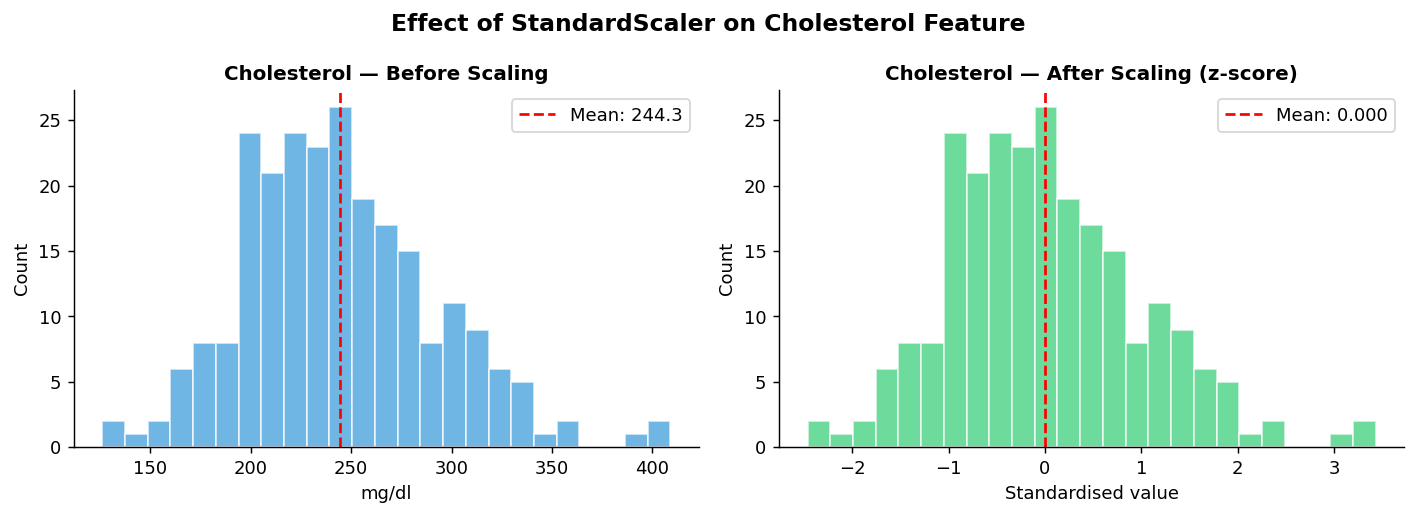

Saved to plots/scaling_effect.png


In [ ]:
# Visualise the effect of scaling on one feature
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(X_train['chol'], bins=25, color='#3498db', alpha=0.7, edgecolor='white')
axes[0].set_title('Cholesterol — Before Scaling', fontsize=11, fontweight='bold')
axes[0].set_xlabel('mg/dl')
axes[0].set_ylabel('Count')
axes[0].axvline(X_train['chol'].mean(), color='red', linestyle='--', label=f"Mean: {X_train['chol'].mean():.1f}")
axes[0].legend()

axes[1].hist(X_train_scaled_df['chol'], bins=25, color='#2ecc71', alpha=0.7, edgecolor='white')
axes[1].set_title('Cholesterol — After Scaling (z-score)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Standardised value')
axes[1].set_ylabel('Count')
axes[1].axvline(X_train_scaled_df['chol'].mean(), color='red', linestyle='--',
                label=f"Mean: {X_train_scaled_df['chol'].mean():.3f}")
axes[1].legend()

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Effect of StandardScaler on Cholesterol Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/scaling_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/scaling_effect.png")

## 3.9 Step 8 — Save Preprocessed Data

In [ ]:
import os
import joblib

# Create data folder if it doesn't exist
os.makedirs("data", exist_ok=True)

# Save all preprocessed artifacts
joblib.dump(X_train_scaled, 'data/X_train.pkl')
joblib.dump(X_test_scaled,  'data/X_test.pkl')
joblib.dump(y_train,        'data/y_train.pkl')
joblib.dump(y_test,         'data/y_test.pkl')

print("All files saved successfully in the data folder!")

All files saved successfully in the data folder!


## 3.10 Preprocessing Checklist Summary

| Step | Action | Result |
|---|---|---|
| Missing values | Checked | None found ✅ |
| Duplicate rows | Checked | None found ✅ |
| Domain validation | Applied | All features within plausible ranges ✅ |
| Outlier handling | IQR analysis | Retained (clinically valid) ✅ |
| Feature classification | Continuous vs Categorical | Documented ✅ |
| Train/test split | 80/20, stratified, random_state=42 | Preserved class balance ✅ |
| Feature scaling | StandardScaler (fit on train only) | No data leakage ✅ |
| Artefacts saved | .pkl and .csv | Ready for Stage 4–6 ✅ |

---
**Next Stage →** `04_eda.ipynb`